Purpose of this notebook is to test fast histogram generation tool for peak statistics analysis.

In [1]:
#Adding current repo to path because it wasn't there
import sys
import os
print(sys.path)
sys.path.append(os.path.abspath('/home/av_linux/AIRXD-CNN'))

['/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python311.zip', '/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python3.11', '/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python3.11/lib-dynload', '', '/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python3.11/site-packages', '/home/av_linux/AIRXD-ML-PUB']


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import imageio as iio
import os
from glob import glob
from airxd_cnn.poni_parse import convert_to_imctrl
import airxd_old
from airxd.mask import MASK
from airxd_cnn.transforms import powder_normalize
import importlib
import pyFAI
from scipy import ndimage
from scipy.ndimage import label
from skimage.measure import regionprops
from airxd_cnn.poni_parse import parse_poni_file, create_2theta_map_poni


In [4]:
def filter_connected_components_by_size(mask, min_size, max_size=None):
    """
    Filters connected components in the mask based on size.
    
    Parameters:
        mask (ndarray): Binary mask where spots are marked as 1, and the background is 0.
        min_size (int): Minimum number of pixels for a connected component to be kept.
        max_size (int, optional): Maximum number of pixels for a connected component to be kept. If None, no upper limit.
        
    Returns:
        filtered_mask (ndarray): Mask with only the connected components that meet the size criteria.
    """
    # Label each connected component in the binary mask
    labeled_mask, _ = label(mask)
    
    # Initialize an empty mask to hold the filtered components
    filtered_mask = np.zeros_like(mask)
    
    # Get properties of labeled regions
    regions = regionprops(labeled_mask)
    
    for region in regions:
        # Check the size of each region
        region_size = region.area
        if region_size >= min_size and (max_size is None or region_size <= max_size):
            # Add this region to the filtered mask
            filtered_mask[labeled_mask == region.label] = 1
    
    return filtered_mask

# Create circular mask (mandatory)

In [5]:
#Directory info
#----------------
example_im_dir = '../data/from_martin/Texture_Examples/Shanece/'
example_im_files = glob(example_im_dir + '*.tiff')
example_im_files.sort()
print(example_im_files)

#Masking
#----------------
idx = 1
im = iio.v2.volread(example_im_files[idx])
#Note to future self. Do NOT normalize the images before using median finder or else it simply won't work.
normalized_im = powder_normalize(im)

#Mask


['../data/from_martin/Texture_Examples/Shanece/LaB6Shanece.tiff', '../data/from_martin/Texture_Examples/Shanece/Shanece.tiff']


In [6]:
def create_circular_mask(height, width, radius):
    """
    Creates a mask with a circle of 1's at the center and 0's elsewhere.
    
    Parameters:
    -----------
    height : int
        Height of the rectangular mask
    width : int
        Width of the rectangular mask
    radius : float
        Radius of the circular region to set as 1's
        
    Returns:
    --------
    mask : numpy.ndarray
        2D array with 1's in a circle at the center and 0's elsewhere
    """
    # Create indices arrays
    y, x = np.ogrid[:height, :width]
    
    # Get center coordinates
    center_y, center_x = height // 2, width // 2
    
    # Calculate squared distance from center
    # (using squared distance avoids computing square roots)
    dist_squared = (x - center_x)**2 + (y - center_y)**2
    
    # Create mask (0 outside circle, 1 inside circle)
    mask = np.zeros((height, width))
    mask[dist_squared <= radius**2] = 1
    
    return mask


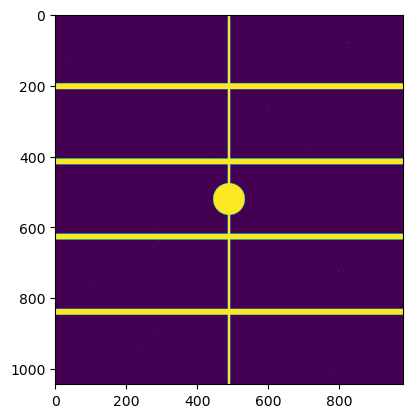

In [6]:
im_mask = np.zeros_like(im)
im_mask[im < 1] = 1
center_circle_mask = create_circular_mask(im.shape[0], im.shape[1], 45)
im_mask = np.logical_or(im_mask, center_circle_mask)

plt.imshow(im_mask)
plt.show()

# Data Import (Mandatory)

In [7]:
example_im_dir = '../data/from_martin/Martin_Variable_Sapphire_Spots/'
example_im_files = glob(example_im_dir + '*.Tiff')
example_im_files.sort()
example_im_files

['../data/from_martin/Martin_Variable_Sapphire_Spots/HK-2_25keV_213mm_30secs_rt-1000_05Ar  0031.Tiff',
 '../data/from_martin/Martin_Variable_Sapphire_Spots/HK-2_25keV_213mm_30secs_rt-1000_05Ar  0181.Tiff',
 '../data/from_martin/Martin_Variable_Sapphire_Spots/HK-2_25keV_213mm_30secs_rt-1000_05Ar  0231.Tiff',
 '../data/from_martin/Martin_Variable_Sapphire_Spots/HK-2_25keV_213mm_30secs_rt-1000_05Ar  0251.Tiff',
 '../data/from_martin/Martin_Variable_Sapphire_Spots/HK-2_25keV_213mm_30secs_rt-1000_05Ar  0351.Tiff',
 '../data/from_martin/Martin_Variable_Sapphire_Spots/HK-3_25keV_213mm_30secs_rt-1000_05Ar  0001.Tiff',
 '../data/from_martin/Martin_Variable_Sapphire_Spots/HK-3_25keV_213mm_30secs_rt-1000_05Ar  0211.Tiff',
 '../data/from_martin/Martin_Variable_Sapphire_Spots/HK-4_25keV_213mm_30secs_1000-rt_05Ar  0151.Tiff',
 '../data/from_martin/Martin_Variable_Sapphire_Spots/HK-4_25keV_213mm_30secs_rt-1000_05Ar  0001.Tiff',
 '../data/from_martin/Martin_Variable_Sapphire_Spots/HK-4_25keV_213mm_30s

In [186]:
example_im_files[11]

'../data/from_martin/Martin_Variable_Sapphire_Spots/HK-6_25keV_213mm_30secs_rt-1000_05Ar  0091.Tiff'

In [8]:
poni_path = '../data/from_martin/Martin_Variable_Sapphire_Spots/Calibration/LaB6_25keV_212mm_Pilatus_120623_1400.poni'
# poni_path = '../data/from_martin/Texture_Examples/Shanece/LaB6Shanece.poni'
# pyfai_poni_path = '../data/from_martin/Texture_Examples/Amon/LaB6Amon.poni'


#IMCTRL version of Poni_path for masking
controls = convert_to_imctrl(poni_path)
mask = MASK(controls = controls, shape = (1043, 981))

#Direct computation of 2theta map
poni_params = parse_poni_file(poni_path)
theta_map, azm_map = create_2theta_map_poni(poni_params,im.shape)

#PyFAI ponipath object for integration
ai = pyFAI.load(poni_path)

#Directory info
#----------------
example_im_dir = '../data/from_martin/Martin_Variable_Sapphire_Spots/'
# example_im_dir = '../data/from_martin/Texture_Examples/Shanece/'
example_im_files = glob(example_im_dir + '*.Tiff')
example_im_files.sort()

#Masking
#----------------
idx = 5
im = iio.v2.volread(example_im_files[idx])
#Note to future self. Do NOT normalize the images before using median finder or else it simply won't work.
normalized_im = powder_normalize(im)

#Median filter
#Resetting the theta range to max instead of default ([0.8 17] approx)
controls['IOtth'] = [0.5, 29]#[0.032, 30.15]
mask = MASK(controls, shape= im.shape)

im_to_mask = im
esdmul_mask = 1.5

result = mask.AutoSpotMask(im_to_mask, esdmul_mask, numchans=300)
extreme_result = mask.AutoSpotMask(im_to_mask, 10.0, numchans=300)

#Mask thresholding
#-------------------
sigma = 2.5  # Adjust this value for different smoothing levels
threshold = 0.75
# Apply island masking first
# island_mask = filter_connected_components_by_size(result, min_size = 2)
smoothed_mask = ndimage.gaussian_filter(result, sigma=sigma)

thresholded_mask = (smoothed_mask > threshold).astype(float)

#Additional thresholding for all super tiny values
thresholded_mask[im<5] = 1

# thresholded_mask = thresholded_mask | extreme_result



Tam length: 1023183
TA length: 1023183
Band length: 1023183
TThs length: 300
Starting up C code
esdmul: 1.5
Tam length: 1023183
TA length: 1023183
Band length: 1023183
TThs length: 300
Starting up C code
esdmul: 10.0


## Troubleshooting 2theta map consistency

In [106]:
def overlay_ring_on_image(base_image, distance_image, target_distance, 
                         ring_width=1, alpha=0.6):
    """
    Overlay a colored ring on a base image with transparency.
    
    Parameters:
    - base_image: 2D numpy array (the underlying image)
    - distance_image: 2D numpy array with distance values
    - target_distance: distance at which to create the ring
    - ring_width: thickness of the ring
    - alpha: transparency of the ring (0=transparent, 1=opaque)
    """
    # Create the ring mask
    half_width = ring_width / 2
    ring_mask = (distance_image >= target_distance - half_width) & \
                (distance_image <= target_distance + half_width)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Display the base image in grayscale
    ax.imshow(base_image, cmap='gray', alpha=1.0)
    
    # Create a masked array for the ring (only show ring pixels)
    ring_overlay = np.ma.masked_where(~ring_mask, distance_image)
    
    # Overlay the ring in red with transparency
    ax.imshow(ring_overlay, cmap='Reds', alpha=alpha, vmin=target_distance-ring_width, vmax=target_distance+ring_width)
    
    ax.set_title(f'Ring at distance {target_distance} (α={alpha})')
    plt.colorbar(ax.images[1], ax=ax, label='Distance', shrink=0.8)
    
    return fig, ax

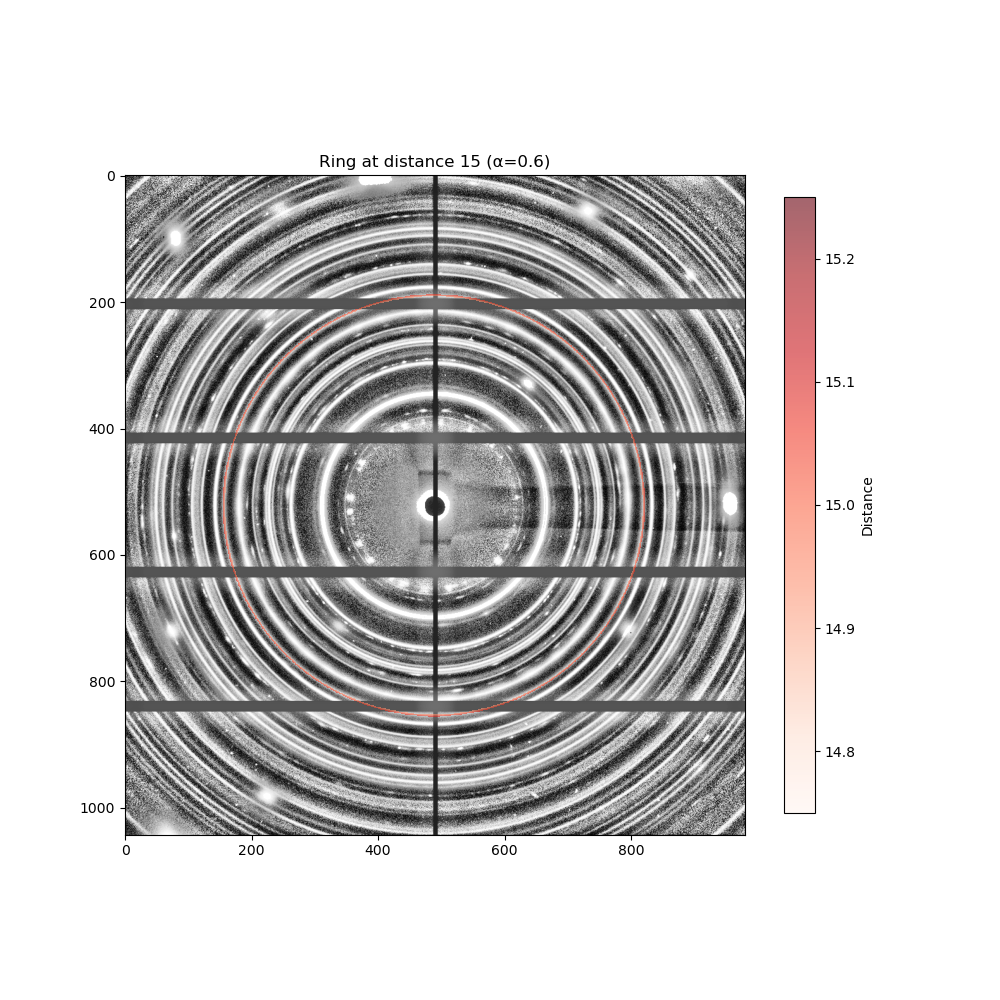

In [147]:
target_theta = 15
ring_thickness = 0.25
ring_val = 1

fig, ax = overlay_ring_on_image(normalized_im, theta_map, target_distance = target_theta,
                                ring_width = ring_thickness, alpha = 0.6)

plt.show()


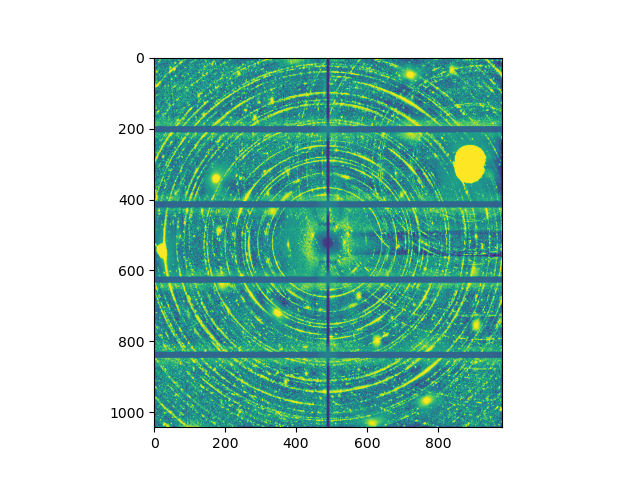

In [108]:
fig = plt.figure()
plt.imshow(normalized_im)
plt.show()

Testing out additional extreme outlier removal

In [ ]:
# bool_thresh = thresholded_mask.astype(bool)
# bool_extreme = extreme_result.astype(bool)

# thresholded_mask = (np.logical_or(bool_thresh,bool_extreme)).astype(float)

Integration and plotting to see which rings to look at

## Integration

In [103]:
pyfai_poni_path = '../data/from_martin/Texture_Examples/Shanece/LaB6Shanece_pyfai.poni'
ai_v2 = pyFAI.load(pyfai_poni_path)

In [81]:
#Integration 

#Test out PyFAI integration on im as well as im with mask
# im[im < 5] = 0

#Regular integration mask
regular_integration_mask = np.zeros_like(im)
regular_integration_mask[im < 20] = 1
center_circle_mask = create_circular_mask(im.shape[0], im.shape[1], 80)
regular_integration_mask = np.logical_or(regular_integration_mask, center_circle_mask)

#Integration mask with tailored mask
integration_mask = np.logical_or(thresholded_mask, center_circle_mask)

#Note the masks are masking OUT what you want to keep out (i.e. 1 means do not pick)
normal_integration = ai.integrate1d(im, 2500, mask = regular_integration_mask, unit = "2th_deg",
                                       method = ("full", "histogram", "cython"), correctSolidAngle=True,
                                       polarization_factor = 0.99)
masked_integration = ai.integrate1d(im, 2500, mask = integration_mask, unit = "2th_deg")

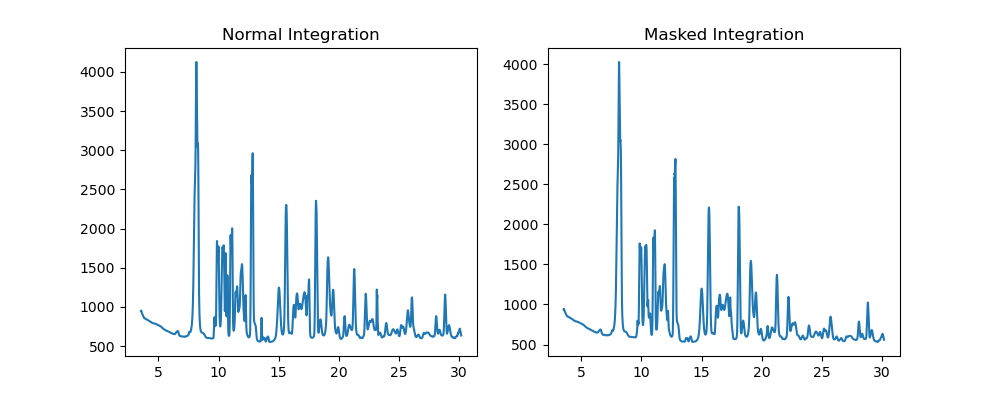

In [82]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].plot(*normal_integration)
ax[0].set_title('Normal Integration')
# ax[0].set_ylim([250, 370])

ax[1].plot(*masked_integration)
ax[1].set_title('Masked Integration')
plt.show()

# Logarithmic Histogram Approach (Skip for now, shelved)

Below is the testing code for the histogram generation

To compile, run: python setup_cpp_scripts.py build_ext --inplace

Note to self: Every time you re-compile, check that the mask value needed to "use" a pixel is 0. (Claude thinks it's a 1, so we're only processing pixels that should be masked instead)

In [17]:
from c_algorithms.logarithmic_histogram import process_logarithmic_histograms

In [18]:
def normalize_and_histogram(img, TA, mask, num_angles = 110, num_bins=100,
                            min_std = 1, max_std = 1):
    """
    img : numpy.ndarray (N x M)
          powder diffraction image (raw, unnormalized)
    TA :  numpy.ndarray (N x M)
          theta-azimuthal map (N X M)
    mask : numpy.ndarray (N x M)
          masking map (N X M)
    num_angles: number of unique rings 
    num_bins : number of bins to be used in histogram
    min_val : minimum standard deviation from mean for log bin
    max_val : max standard deviation from mean for log bin
    """

    img = np.asarray(img, dtype = np.float64)
    TA = np.asarray(TA, dtype = np.float64)
    mask = np.asarray(mask, dtype = np.int32)

    if not np.all(np.isin(mask, [0, 1])):
        raise ValueError("All values in mask must be binary")
    
    theta_val = np.linspace(np.min(TA),
                            np.max(TA),
                            num_angles)

    histograms = process_logarithmic_histograms(
        img, TA, mask, theta_val,
        num_bins, min_std, max_std)

    return histograms
    
    

In [19]:
import time

In [24]:
ignore_keys = ['bin_edges', 'mean', 'std_dev', 'min_val', 'max_val', 'group_counts']

start_time = time.perf_counter()
hist = normalize_and_histogram(im, mask.TA, thresholded_mask)
hist_angles = list(hist.keys())
bin_edges = hist.pop('bin_edges')
hist_arrays = [hist[key] for key in hist.keys() if key not in ignore_keys]
end_time = time.perf_counter()
print(f'Execution time: {end_time - start_time} seconds')

Execution time: 0.03146412599016912 seconds


In [43]:
hist_arrays[30:40]

[array([0.9516129 , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.0016129 , 0.00483871, 0.00322581, 0.00483871,
        0.        , 0.00806452, 0.        , 0.        , 0.00806452,
        0.00483871, 0.00483871, 0.00322581, 0.00322581, 0.0016129 ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

Text(0.5, 1.0, 'Array from theta = 9.431954664631037')

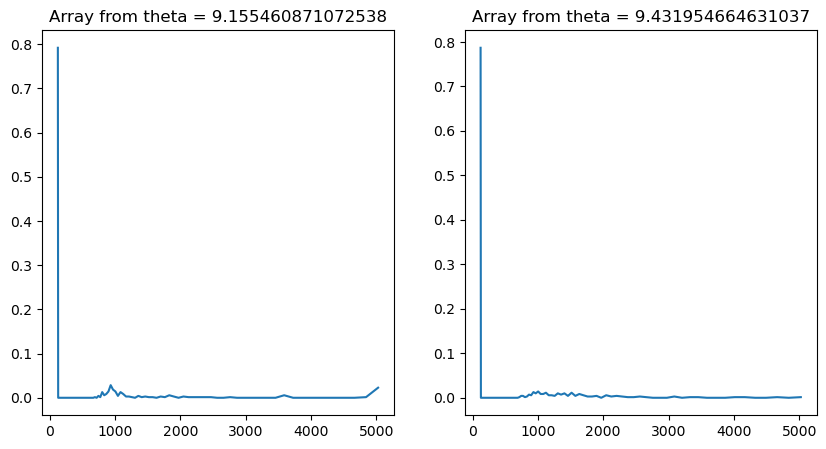

In [47]:
i_1, i_2 = 38, 39
x_axs = np.linspace(-2,2,100)
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].plot(bin_edges[:-1],hist_arrays[i_1])
ax[0].set_title(f'Array from theta = {hist_angles[i_1]}')
ax[1].plot(bin_edges[:-1],hist_arrays[i_2])
ax[1].set_title(f'Array from theta = {hist_angles[i_2]}')

K-means clustering visualization

In [29]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

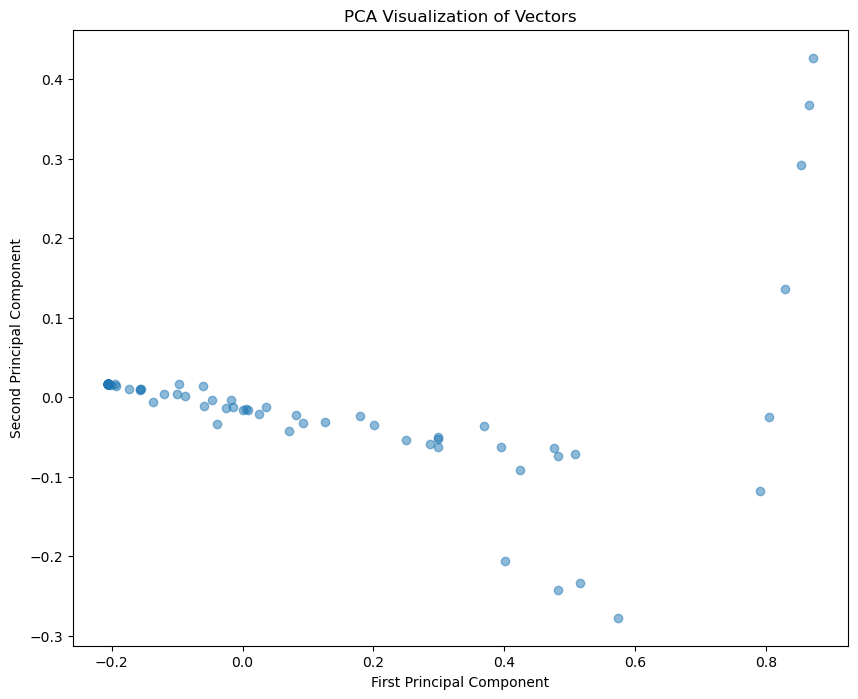

In [30]:
# Stack arrays into 2D array
X = np.vstack(hist_arrays)

# Reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title('PCA Visualization of Vectors')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.show()

In [ ]:
# Perform clustering
n_clusters = 3  # adjust as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X)

# Visualize with PCA
X_pca = PCA(n_components=2).fit_transform(X)

# Plot with colors for clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.colorbar(scatter)
plt.title('PCA Visualization with K-means Clusters')
plt.show()

1023183

# Azimuthal binning approach

In [14]:
%matplotlib widget

from c_algorithms.azimuthal_processing import azimuthal_binning, count_spikes
import time
from mpl_toolkits.axes_grid1 import make_axes_locatable
import mplcursors

In [15]:
def create_azimuthal_bins(img, TA, mask, num_angles = 150):
    """
    img : numpy.ndarray (N x M)
          powder diffraction image (raw, unnormalized)
    TA :  numpy.ndarray (N x M)
          theta-azimuthal map (N X M)
    mask : numpy.ndarray (N x M)
          masking map (N X M)
    num_angles: number of unique rings 
    num_bins : number of bins to be used in histogram
    min_val : minimum standard deviation from mean for log bin
    max_val : max standard deviation from mean for log bin
    """

    img = np.asarray(img, dtype = np.float64)
    TA = np.asarray(TA, dtype = np.float64)
    mask = np.asarray(mask, dtype = np.int32)

    if not np.all(np.isin(mask, [0, 1])):
        raise ValueError("All values in mask must be binary")
    
    theta_val = np.linspace(np.min(TA),
                            np.max(TA),
                            num_angles)
    
    start_time = time.perf_counter()
    rings, mean = azimuthal_binning(
        img, TA, theta_val, mask)
    print(f'Execution time: {time.perf_counter() - start_time}')

    return rings, mean, theta_val
    
    

In [83]:
n_theta_bins = 1000
azimuthal_rings, im_mean, theta = create_azimuthal_bins(im, theta_map, thresholded_mask,
                                                        num_angles = n_theta_bins)

Execution time: 0.06447805999778211


Going to plot the diffraction patterns so I can see which thetas are usable

In [84]:
def interactive_plot(im_to_plot, default_im,
                     mask_obj, mask,
                     plot_title):
    # Create figure with two subplots
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))

    # Left subplot
    im1 = ax[0].imshow(im_to_plot, cmap='binary')
    im2 = ax[0].imshow(mask_obj.TA, cmap='autumn', alpha=0.4)
    ax[0].set_title(plot_title)

    # Right subplot
    im3 = ax[1].imshow(im_to_plot, cmap='binary', origin='lower')
    im4 = ax[1].imshow(mask_obj.TA, cmap='autumn', alpha=0.4)
    im5 = ax[1].imshow(np.ma.masked_where(mask == 0, mask), cmap='cool', alpha=0.5)
    # im5 = ax[1].imshow(np.ma.masked_where(result == 1, result), cmap='cool', alpha=0.5)

    # Add colorbars with adjusted size
    divider0 = make_axes_locatable(ax[0])
    cax0 = divider0.append_axes("right", size="5%", pad=0.05)
    cbar1 = fig.colorbar(im2, cax=cax0, label='Angle (degrees)')

    divider1 = make_axes_locatable(ax[1])
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    cbar2 = fig.colorbar(im4, cax=cax1, label='Angle (degrees)')

    # Make plots interactive
    cursor1 = mplcursors.cursor(im2)
    @cursor1.connect("add")
    def on_add(sel):
        x, y = int(sel.target[0]), int(sel.target[1])
        angle = mask_obj.TA[y, x]
        z_val = default_im[y,x]
        sel.annotation.set_text(f'Angle: {angle:.2f}°\nx: {x}\ny: {y}\nraw: {z_val:.1f}\nmask: {mask[y,x]}')
        
    cursor2 = mplcursors.cursor(im4)
    @cursor2.connect("add")
    def on_add(sel):
        x, y = int(sel.target[0]), int(sel.target[1])
        angle = mask_obj.TA[y, x]
        z_val = default_im[y,x]
        sel.annotation.set_text(f'Angle: {angle:.2f}°\nx: {x}\ny: {y}\nraw: {z_val:.1f}\nmask: {mask[y,x]}')

    # Turn off axes
    ax[0].axis('off')
    ax[1].axis('off')

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

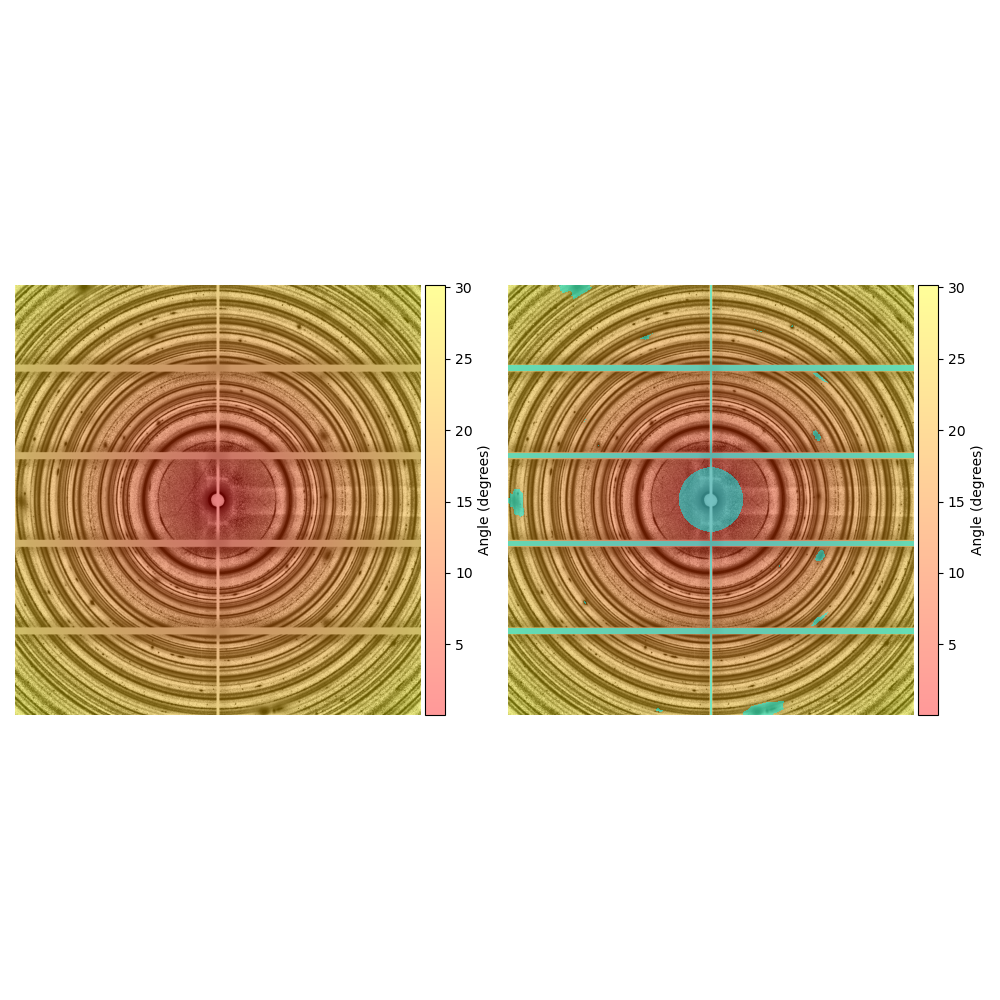

In [85]:
interactive_plot(normalized_im, im,
                 mask, integration_mask, '')

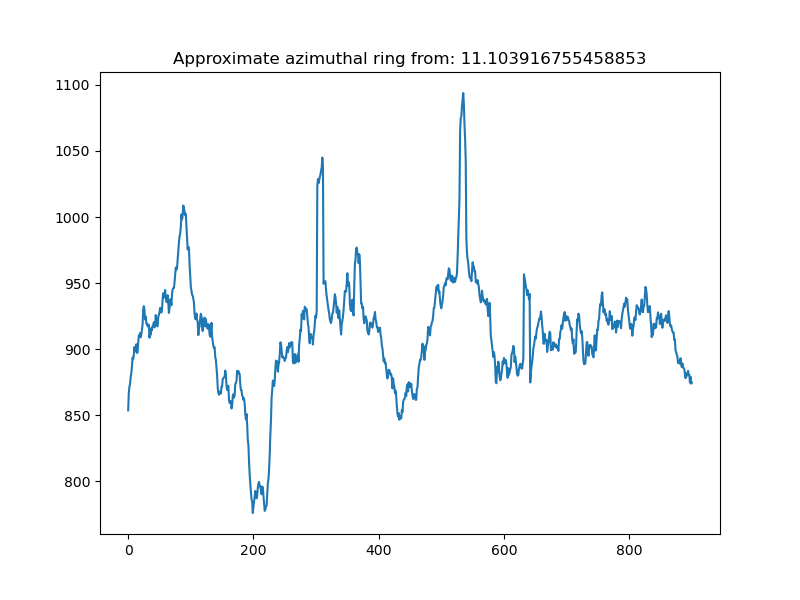

In [200]:
angle =  11.1 #in theta degree units
theta_val = np.linspace(np.min(mask.TA),
                            np.max(mask.TA),
                            n_theta_bins)
i = (np.abs(theta_val - angle)).argmin()
window_size = 10
y_plt = azimuthal_rings[i]
y_plt = np.convolve(y_plt, np.ones(window_size)/window_size, mode='valid')
x_plt = np.arange(0,len(y_plt),1)

new_fig = plt.figure(figsize=(8, 6))
plt.plot(x_plt,y_plt)
plt.title(f'Approximate azimuthal ring from: {theta_val[i]}')
plt.show()

# Testing out spectral processing/binning

In [86]:
import airxd_cnn.spectral_processing
importlib.reload(airxd_cnn.spectral_processing)
from airxd_cnn.spectral_processing import fast_spectral_entropy, _calculate_spectral_entropy_single, fast_spectra_binning, calculate_acf_entropy
from scipy import signal
from sklearn.decomposition import PCA
from scipy.signal import find_peaks

## Peak finder so we can highlight the points of actual interest on the scatter

In [20]:
import airxd_cnn.spectral_processing
importlib.reload(airxd_cnn.spectral_processing)

<module 'airxd_cnn.spectral_processing' from '/home/av_linux/AIRXD-CNN/airxd_cnn/spectral_processing.py'>

In [21]:
from airxd_cnn.spectral_processing import calculate_acf_entropy, fast_spectral_entropy,_calculate_spectral_entropy_single

In [22]:
def find_xrd_peaks(spectrum,
                   height=None, distance=None, prominence=None):
    """
    A quick and dirty peak finder for XRD spectra.
    
    Parameters:
    -----------
    spectrum : numpy.ndarray
        1D array containing the intensity data of the XRD spectrum
    height : float, optional
        Minimum height of peaks. Default is 0.1*max(spectrum)
    distance : int, optional
        Minimum distance between peaks. Default is len(spectrum)/20
    prominence : float, optional
        Minimum prominence of peaks. Default is 0.05*max(spectrum)
    
    Returns:
    --------
    peaks : numpy.ndarray
        Indices of detected peaks in the spectrum
    """


    # Set default parameters if not provided
    if height is None:
        height = 0.03 * np.max(spectrum)  # Lower threshold to catch smaller peaks
    if distance is None:
        distance = 4  # Shorter distance to catch closely spaced peaks
    if prominence is None:
        prominence = 0.02 * np.max(spectrum)  # Lower prominence to catch sharper peaks
    
    # Find peaks
    peaks, _ = find_peaks(spectrum, height=height, distance=distance, prominence = prominence)
    
    return peaks

In [87]:
spectrum = masked_integration[1]
global_max = np.max(spectrum)
peaks, _ = find_peaks(masked_integration[1], height = 0.001 * global_max,
                      distance = 2)

In [88]:
#Leave out last few theta values because of outliers
azimuthal_valid = azimuthal_rings[5:-14]
theta_valid =theta[5:-15]


spectral_bins, spectral_bin_vals = fast_spectra_binning(azimuthal_valid, bins=20)



#Find the peaks within the spectra
global_max = np.max(masked_integration[1])
peak_indices = find_xrd_peaks(masked_integration[1], height = 0.001 * global_max,
                              distance = 4,
                              prominence = 0.005 * global_max)
prominent_indices = []
#Find the coresponding idxs from theta
for idx in peak_indices:
    fine_theta = masked_integration[0][idx]
    coarse_idx = np.argmin(abs(theta_valid - fine_theta))
    prominent_indices.append(coarse_idx)

In [89]:
#Get corrected intensity vector accounting for coarse-grained theta
#You'll get some subset of the integrated 1D pattern with theta vals corresponding to the coarse-grained 2theta values in "theta"
coarse_vals = []
coarse_acf = []
coarse_spectral_entropy = []

for i, coarse_theta in enumerate(theta_valid):
    fine_idx = np.argmin(abs(coarse_theta - masked_integration[0]))
    coarse_vals.append(masked_integration[1][fine_idx])
    if i in prominent_indices and coarse_theta < 29:
        #Quick and dirty extreme value removal
        azimuthal_valid[i][azimuthal_valid[i] > 5e4] = np.median(azimuthal_valid[i])

        #Calculate acf entropy and spectral entropy
        coarse_acf_i = calculate_acf_entropy(azimuthal_valid[i],max_lag=60)
        single_entropy_i = _calculate_spectral_entropy_single(azimuthal_valid[i])[0]
        if np.isnan(coarse_acf_i) or np.isnan(single_entropy_i):
            coarse_acf.append(0)
            coarse_spectral_entropy.append(0)
        else:
            coarse_acf.append(coarse_acf_i)
            coarse_spectral_entropy.append(single_entropy_i)
    else:
        coarse_acf.append(0)
        coarse_spectral_entropy.append(0)
    
    

# Added second dimension to add to feature vector
# Excluded the first element because these theta vals correspond to "histogram bins" for the azimuthal binning algorithm above
coarse_vals = np.array(coarse_vals).transpose()[:,None]
# coarse_vals = np.log(coarse_vals) #Intensity values
coarse_vals /= np.max(coarse_vals)

#Turn entropies into arrays
coarse_acf = np.array(coarse_acf).transpose()[:,None]
coarse_acf /= np.max(coarse_acf)

coarse_spectral_entropy = np.array(coarse_spectral_entropy).transpose()[:,None]
    

## Visualizing the peaks

In [90]:
def visualize_xrd_peaks(two_theta, intensity, peaks=None, figsize=(12, 6), 
                        marker_size=100, marker_color='red', plot_prominences=True):
    """
    Visualize XRD spectrum with detected peaks highlighted.
    
    Parameters:
    -----------
    two_theta : numpy.ndarray
        1D array containing the 2θ values of the XRD spectrum
    intensity : numpy.ndarray
        1D array containing the intensity data of the XRD spectrum
    peaks : numpy.ndarray, optional
        Indices of detected peaks in the spectrum
    figsize : tuple, optional
        Figure size (width, height) in inches
    marker_size : int, optional
        Size of peak markers
    marker_color : str, optional
        Color of peak markers
    plot_prominences : bool, optional
        Whether to visualize peak prominences
    """
    plt.figure(figsize=figsize)
    
    # Plot the XRD spectrum
    plt.plot(two_theta, intensity, 'b-', label='XRD Spectrum')
    
    # If peaks are provided, plot them as scatter points
    if peaks is not None and len(peaks) > 0:
        peak_positions = two_theta[peaks]
        peak_intensities = intensity[peaks]
        plt.scatter(peak_positions, peak_intensities, color=marker_color, s=marker_size, 
                    marker='^', label=f'Detected Peaks ({len(peaks)})')
        
    
    plt.xlabel('2θ (degrees)')
    plt.ylabel('Intensity (a.u.)')
    plt.title('XRD Spectrum with Detected Peaks')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    return plt.gcf()

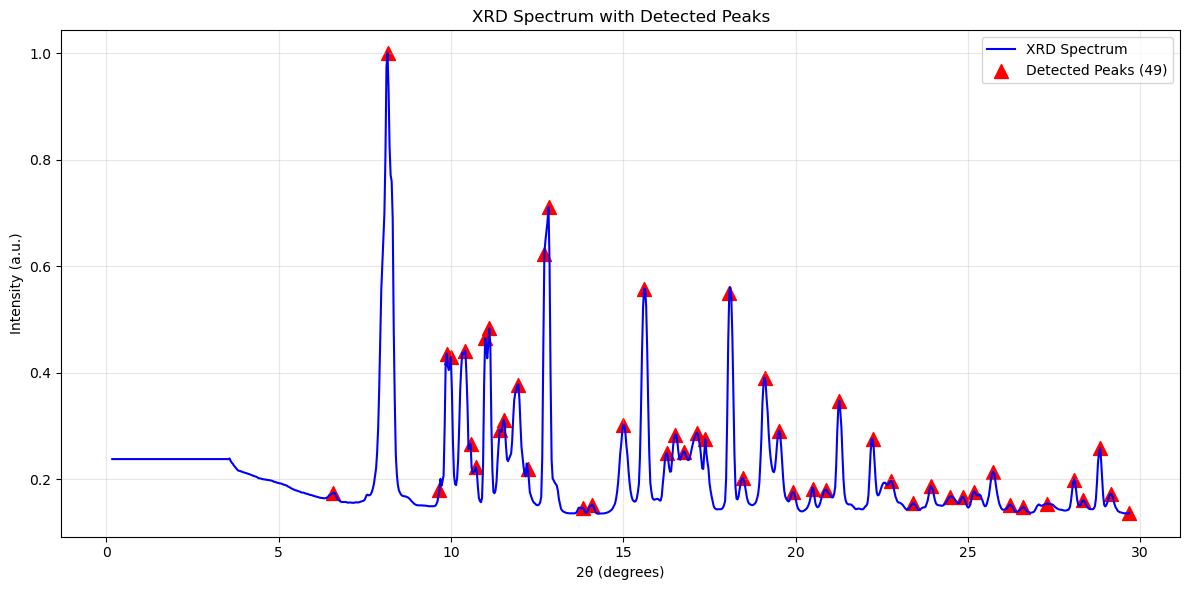

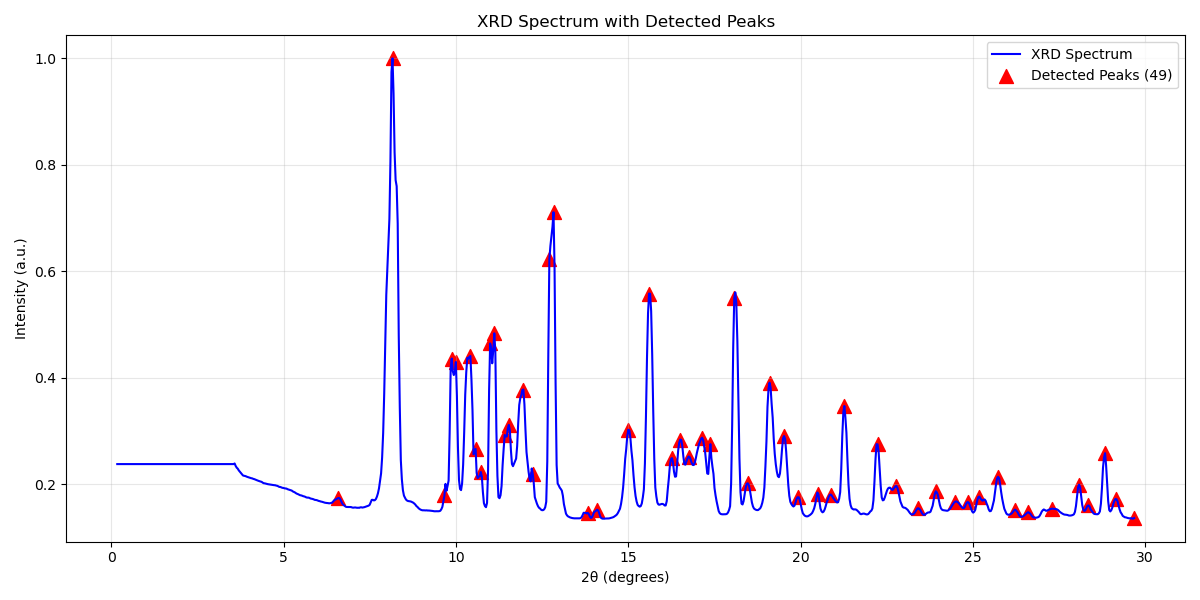

In [91]:
visualize_xrd_peaks(theta_valid, coarse_vals,np.array(prominent_indices))

## Plotting PCA results

### Custom adding a few prominent indices that were missed

In [303]:
theta_to_find = 18.89
coarse_idx = np.argmin(abs(theta_valid - theta_to_find))
print(coarse_idx)

621


In [296]:
prominent_indices

[195,
 222,
 264,
 269,
 338,
 347,
 361,
 389,
 424,
 439,
 457,
 491,
 511,
 541,
 550,
 561,
 595,
 605,
 625,
 640,
 649,
 669,
 683,
 748,
 769,
 785,
 800,
 817,
 832,
 844,
 863,
 872,
 894,
 956,
 979]

In [304]:
idx = 625
coarse_spectral_entropy[idx], coarse_acf[idx]

(array([0.00434144]), array([0.99975792]))

**This is for HK-6_25keV_213mm_30secs_rt-1000_05Ar 0091.Tiff specifically**
550, 649, 439

### Continuing

In [92]:
# feature_vector = np.vstack(spectral_bin_vals)
# Add intensity
feature_vector = np.hstack((coarse_spectral_entropy, coarse_acf))

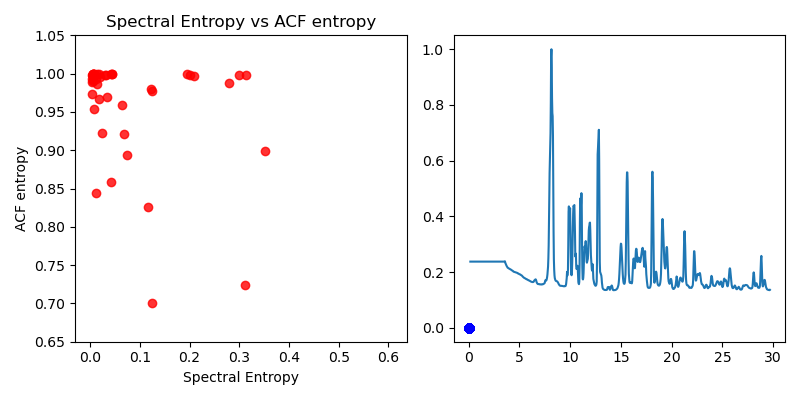

In [105]:
import matplotlib.pyplot as plt
import numpy as np
import mplcursors
from sklearn.decomposition import PCA

# Turn spectral histogram into features
# feature_vector = np.vstack(spectral_bin_vals)
# Add intensity
# feature_vector = np.hstack((feature_vector, coarse_vals))

# Perform PCA
pca = PCA(n_components=2)
transformed_data = pca.fit_transform(feature_vector)

# Indices to highlight and indices to ignore
ignore_indices = []#[i in range(280,296)]#i for i in range(10)]

# Create a mask for points to include (all points except those in ignore_indices)
all_indices = np.arange(len(transformed_data))
overall_mask = np.isin(all_indices, ignore_indices, invert=True)

# Filter out the ignored points
filtered_data = feature_vector[overall_mask]#transformed_data[overall_mask]
filtered_indices = all_indices[overall_mask]

# Create a mask for prominent points within the filtered data
prominent_mask = np.isin(filtered_indices, prominent_indices)

# fig = plt.figure(figsize=(6,6))
fig, axs = plt.subplots(1, 2, figsize = (8,4))

# Plot non-prominent points in blue
scatter_regular = plt.scatter(
    filtered_data[~prominent_mask, 0], 
    filtered_data[~prominent_mask, 1], 
    alpha=0.8,
    color='blue',
    label='Regular points'
)

# Plot prominent points in red
scatter_prominent = axs[0].scatter(
    filtered_data[prominent_mask, 0], 
    filtered_data[prominent_mask, 1], 
    alpha=0.8,
    color='red',
    label='Prominent points'
)

axs[1].plot(theta_valid, coarse_vals)
# axs[1].set_ylim(0.5,1)


axs[0].set_title('Spectral Entropy vs ACF entropy')
axs[0].set_xlabel(f'Spectral Entropy')#({pca.explained_variance_ratio_[0]:.2%})')
axs[0].set_ylabel(f'ACF entropy')# ({pca.explained_variance_ratio_[1]:.2%})')
# axs[0].legend()
axs[0].set_ylim(0.65,1.05)
plt.tight_layout()

# Store the mapping between plot indices and original indices
regular_original_indices = filtered_indices[~prominent_mask]
prominent_original_indices = filtered_indices[prominent_mask]

# Create a combined cursor for both scatter plots
cursor = mplcursors.cursor([scatter_prominent], hover=True)

@cursor.connect("add")
def on_add(sel):
    # Get the artist (which scatter plot was clicked)
    artist = sel.artist
    
    # Instead of using .index, calculate the index based on the coordinates
    x, y = sel.target
    
    if artist == scatter_regular:
        # For regular points
        regular_points = np.column_stack([
            filtered_data[~prominent_mask, 0],
            filtered_data[~prominent_mask, 1]
        ])
        # Find closest point
        distances = np.sum((regular_points - np.array([x, y]))**2, axis=1)
        local_idx = np.argmin(distances)
        original_idx = regular_original_indices[local_idx]
    else:
        # For prominent points
        prominent_points = np.column_stack([
            filtered_data[prominent_mask, 0],
            filtered_data[prominent_mask, 1]
        ])
        # Find closest point
        distances = np.sum((prominent_points - np.array([x, y]))**2, axis=1)
        local_idx = np.argmin(distances)
        original_idx = prominent_original_indices[local_idx]
    
    # Now use the correct original index to get the associated data
    theta_value = theta_valid[original_idx]
    
    # Set the annotation
    sel.annotation.set_text(f'Index: {original_idx}\nTheta: {theta_value:.4f}')
    print(f"Selected point index: {original_idx}, Theta: {theta_value:.4f}")

plt.show()

In [101]:
prominence_idx

6

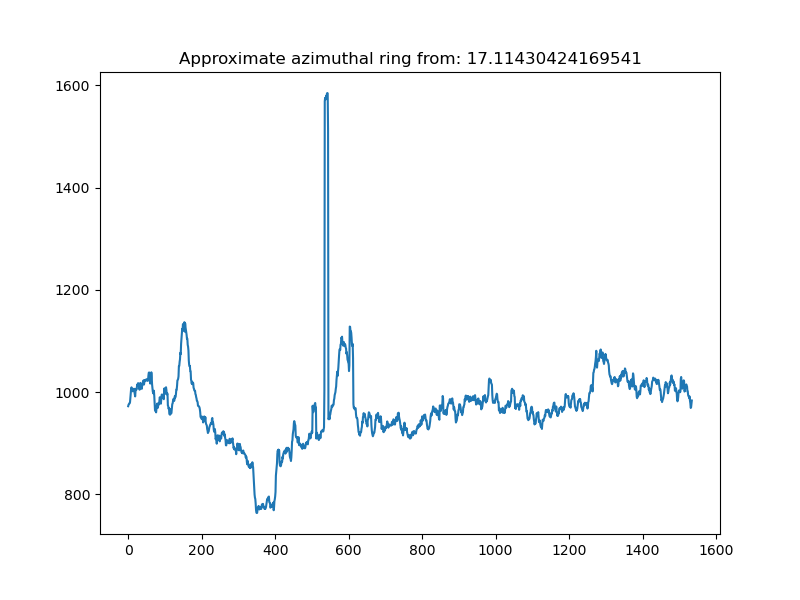

[0.01098002 0.99290139]


In [144]:
angle = 17.10 #in theta degree units
theta_val = np.linspace(np.min(mask.TA),
                            np.max(mask.TA),
                            n_theta_bins)
i = (np.abs(theta_val - angle)).argmin()
window_size = 10
y_plt = azimuthal_rings[i]
y_plt = np.convolve(y_plt, np.ones(window_size)/window_size, mode='valid')
x_plt = np.arange(0,len(y_plt),1)

new_fig = plt.figure(figsize=(8, 6))
plt.plot(x_plt,y_plt)
plt.title(f'Approximate azimuthal ring from: {theta_val[i]}')
plt.show()

coarse_idx = np.argmin(abs(theta_valid - angle))
prominence_idx = np.argmin(abs(prominent_indices - coarse_idx))
print(feature_vector[prominent_indices[prominence_idx],:])


## Looking at FFTs to see any inspiration

In [193]:
#Computing FFT
window_size = 1
cnv_azim_rings = []
for vec in azimuthal_rings:
    if len(vec) > 0:
        cnv_azim_rings.append(np.convolve(vec,np.ones(window_size)/window_size, mode = 'valid'))

fft_azim_rings = []
for vec in cnv_azim_rings:
    vec_max = np.max(vec)
    vec_median = np.median(vec)
    vec[vec >= 0.95*vec_max] = vec_median
    fft_vec = np.fft.fft(vec)
    fft_vec_norm = fft_vec/np.sum(fft_vec)
    fft_azim_rings.append(fft_vec_norm)




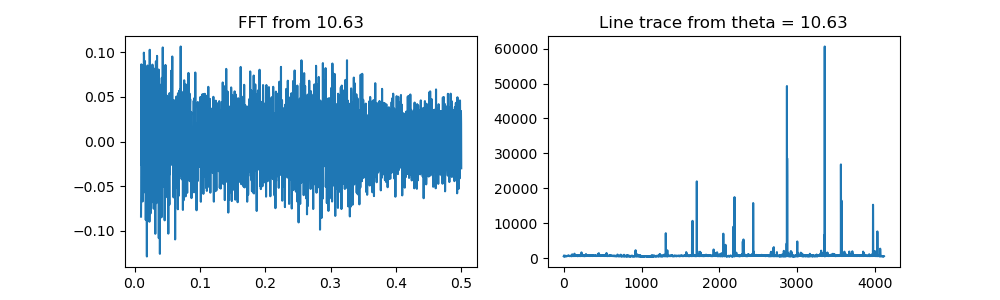

In [194]:
plt.ioff()
angle = 10.62 #in theta degree units
theta_val = np.linspace(np.min(mask.TA),
                            np.max(mask.TA),
                            n_theta_bins)
i = (np.abs(theta_val - angle)).argmin()

#First plot
y_plt = np.fft.fftshift(fft_azim_rings[i])
freqs = np.fft.fftfreq(len(y_plt), 1)
x_plt = np.fft.fftshift(freqs)
x_plt_i = (np.abs(x_plt - 0.01)).argmin()
#Second plot
y_plt_1 = cnv_azim_rings[i]
x_plt_1 = np.arange(len(y_plt_1))
#Entropy calc
spec_entropy, high_spec_entropy = _calculate_spectral_entropy_single(cnv_azim_rings[i])

fig, axs = plt.subplots(1,2,figsize=(10,3))

axs[0].plot(x_plt[x_plt_i:],y_plt[x_plt_i:])
axs[1].plot(x_plt_1,y_plt_1)
# axs[1].set_ylim([0, 3000])
# axs[2].plot(*masked_integration)

# axs[0].set_title(f'Approximate FFT from: {round(theta_val[i],2)} with entropy {round(spec_entropy,2)} and high freq. entropy {round(-np.log(high_spec_entropy),2)}')
axs[0].set_title(f'FFT from {round(theta_val[i],2)}')
axs[1].set_title(f'Line trace from theta = {round(theta_val[i],2)}')
plt.show()

## Spectral Entropies below (fixed outliers screwing up entropy)

In [174]:
entropies = fast_spectral_entropy(azimuthal_rings)
# bins, hist_vals = fast_spectra_binning(azimuthal_rings)

ValueError: zero-size array to reduction operation maximum which has no identity

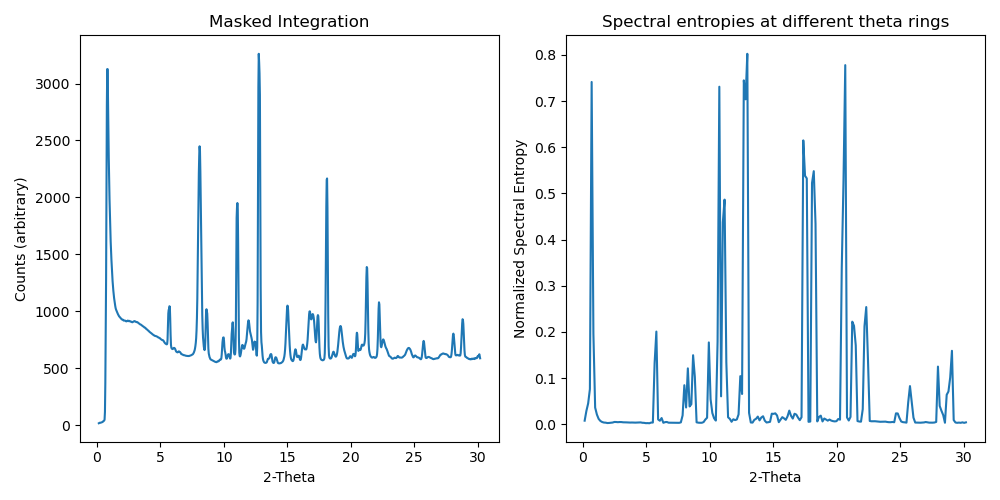

In [63]:
theta_val = np.linspace(np.min(mask.TA),
                            np.max(mask.TA),
                            n_theta_bins)[1:]

# Turn off interactive mode for this cell
# plt.ioff()

# Create a single figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Original theta plot
ax[0].plot(*masked_integration)
ax[0].set_xlabel('2-Theta')
ax[0].set_ylabel('Counts (arbitrary)')
ax[0].set_title('Masked Integration')

# Entropies
ax[1].plot(theta_val, entropies)
ax[1].set_xlabel('2-Theta')
ax[1].set_ylabel('Normalized Spectral Entropy')
ax[1].set_title('Spectral entropies at different theta rings')

# Improve layout
plt.tight_layout()

# Render the plot
plt.show()



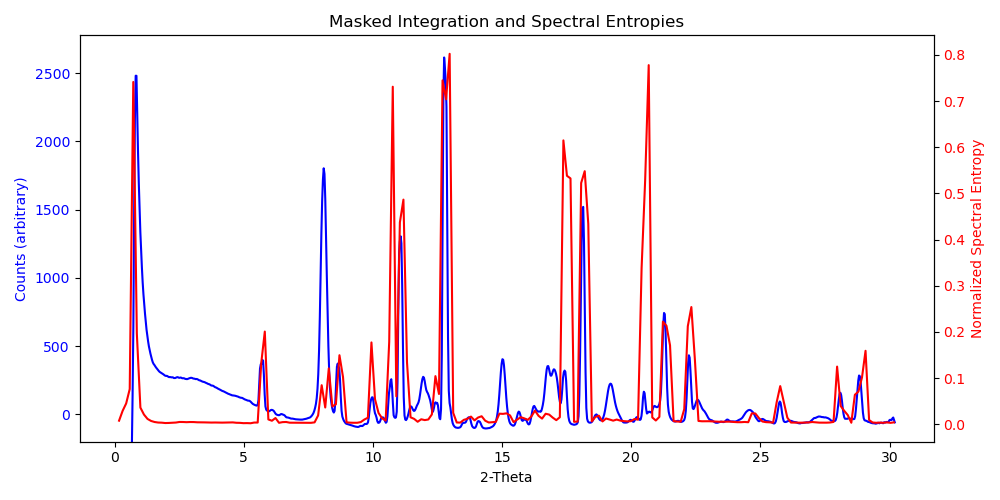

In [64]:
#Same sided plot

# Turn off interactive mode for this cell
# plt.ion()

# Create a single figure with one plot (instead of subplots)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot masked integration on the left y-axis
ax1.plot(masked_integration[0], masked_integration[1] - np.median(masked_integration[1]), color='blue')
ax1.set_xlabel('2-Theta')
ax1.set_ylabel('Counts (arbitrary)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(bottom=-200)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Plot entropies on the right y-axis
ax2.plot(theta_val, entropies, color='red')
ax2.set_ylabel('Normalized Spectral Entropy', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add a title
plt.title('Masked Integration and Spectral Entropies')

# Improve layout
fig.tight_layout()

# Render the plot
plt.show()

Going to calculate intensities of each ring then just do a 2d scatter

In [ ]:
#Convert list of arrays into 2d array
np_avgd_intensities = []
acf_entropies = []
window_size = 10

for i, array in enumerate(azimuthal_rings):
    np_avgd_intensities.append(np.sum(azimuthal_rings[i])/(len(azimuthal_rings[i])+1))

    #ACF
    time_series = azimuthal_rings[i]
    cnv_time_series = np.convolve(time_series, np.ones(window_size)/window_size, mode='valid')
    acf_entropies.append(calculate_acf_entropy(cnv_time_series,max_lag=40))



In [76]:
intensity_range = np.max(np_avgd_intensities) - np.min(np_avgd_intensities)
entropy_range = np.max(entropies) - np.min(entropies)

intensity_range, entropy_range

(2601.442028985507, 0.800152338667813)

In [77]:
np.max(acf_entropies)

nan

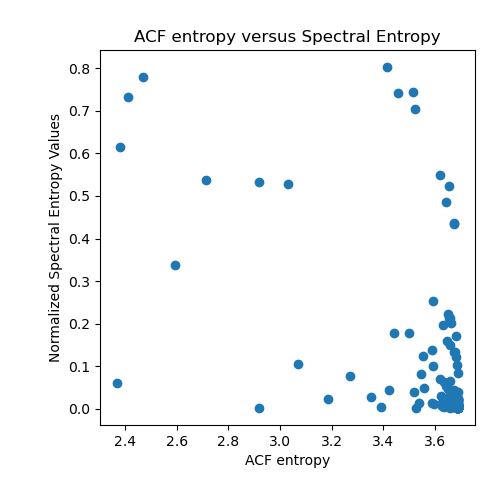

In [78]:
plot_acf_entropies = acf_entropies[1:-1]
plot_entropies = entropies[1:-1]

# Normalize the distance calculation
# Get the range of each dimension
intensity_range = np.max(np_avgd_intensities) - np.min(np_avgd_intensities)
acf_range = np.max(plot_acf_entropies) - np.min(plot_acf_entropies)
entropy_range = np.max(plot_entropies) - np.min(plot_entropies)

plt.ion()

fig = plt.figure(figsize=(5,5))
ax = fig.add_axes([0.2, 0.15, 0.75, 0.75])
im1 = plt.scatter(plot_acf_entropies,plot_entropies)
# plt.xlim(left=600)

plt.xlabel('ACF entropy')
plt.ylabel('Normalized Spectral Entropy Values')
plt.title('ACF entropy versus Spectral Entropy')

# Make plots interactive
cursor1 = mplcursors.cursor(im1)
@cursor1.connect("add")
def on_add(sel):
    # Get the index by finding the closest point
    x, y = sel.target
    # Calculate normalized distances
    norm_x_diff = (plot_acf_entropies - x) / acf_range
    norm_y_diff = (plot_entropies - y) / entropy_range
    distances = (norm_x_diff)**2 + (norm_y_diff)**2
    idx = np.argmin(distances)
    
    # Set the annotation text to show the index
    sel.annotation.set_text(f'Index: {idx}, Theta: {round(theta_val[idx],2)}')
    sel.annotation.set(ha="left")
    sel.annotation.xy_offset = (15, 0)  # Move tooltip to the right
    print(f"Selected point index: {idx}")#theta_val[idx]

# cursor1.annotation_kwargs["ha"] = "left"  # "ha" is horizontal alignment
# cursor1.annotation_kwargs["xytext"] = (15, 0)  # Offset tooltip to the right of the cursor

plt.show()


# Looking at auto-correlation function instead

In [82]:
from statsmodels.tsa.stattools import acf

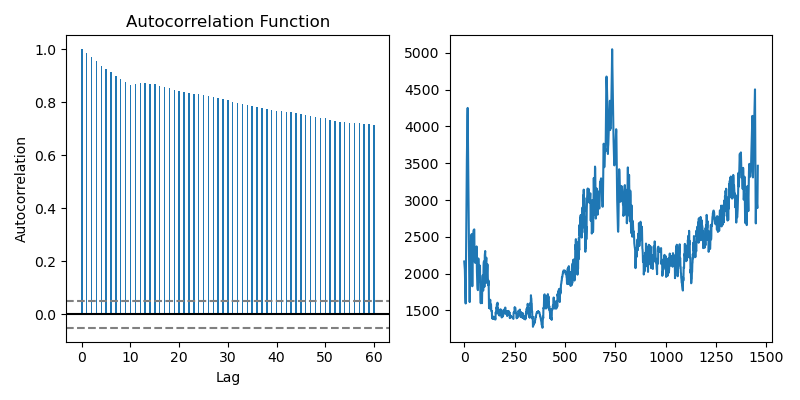

Entropy is 4.091302440335843


In [83]:
angle = 5.8773 #in theta degree units
theta_val = np.linspace(np.min(mask.TA),
                            np.max(mask.TA),
                            n_theta_bins)
i = (np.abs(theta_val - angle)).argmin()
window_size = 10
time_series = azimuthal_rings[i]
cnv_time_series = np.convolve(time_series, np.ones(window_size)/window_size, mode='valid')

acf_values = acf(cnv_time_series, nlags=60, fft = True)

# Plot the autocorrelation function
fig, axs = plt.subplots(1,2,figsize=(8, 4))

axs[0].bar(range(len(acf_values)), acf_values, width=0.3)
axs[0].axhline(y=0, linestyle='-', color='black')
axs[0].axhline(y=-1.96/np.sqrt(len(time_series)), linestyle='--', color='gray')
axs[0].axhline(y=1.96/np.sqrt(len(time_series)), linestyle='--', color='gray')
axs[0].set_xlabel('Lag')
axs[0].set_ylabel('Autocorrelation')
axs[0].set_title('Autocorrelation Function')

axs[1].plot(np.arange(0,len(cnv_time_series)), cnv_time_series)




plt.tight_layout()
plt.show()

print(f"Entropy is {calculate_acf_entropy(cnv_time_series,max_lag=60)}")

# PCA of different combinations

In [84]:
from sklearn.decomposition import PCA

In [ ]:
#Convert list of arrays into 2d array
np_avgd_intensities = []
acf_entropies = []
window_size = 10

for i, array in enumerate(azimuthal_rings[1:-1]):
    np_avgd_intensities.append(np.sum(azimuthal_rings[i])/(len(azimuthal_rings[i])+1))

    #ACF
    # time_series = azimuthal_rings[i]
    # cnv_time_series = np.convolve(time_series, np.ones(window_size)/window_size, mode='valid')
    # acf_entropies.append(calculate_acf_entropy(cnv_time_series,max_lag=40))

ValueError: v cannot be empty

In [85]:
#Going to try PCA of normalized intensities, entropy and acf_entropy
#Rescale everything

#Doing 1:-1 because acf entropies do not calculate at first and last element

pca_avgd_intensities = np_avgd_intensities[1:-1]
pca_acf_entropies = acf_entropies[1:-1]
pca_entropies = entropies[1:-1]

# Normalize the distance calculation
# Get the range of each dimension
acf_range = np.max(pca_acf_entropies) - np.min(pca_acf_entropies)

#Rescale intensities and acf
np_avgd_int_rescaled = pca_avgd_intensities/(np.max(pca_avgd_intensities) - np.min(pca_avgd_intensities))
acf_entropies_rescaled = pca_acf_entropies/(acf_range)

feature_vector = np.stack([acf_entropies_rescaled, pca_entropies,np_avgd_int_rescaled]).transpose()

# Apply PCA
pca = PCA(n_components=3)
transformed_data = pca.fit_transform(feature_vector)


NameError: name 'np_avgd_intensities' is not defined

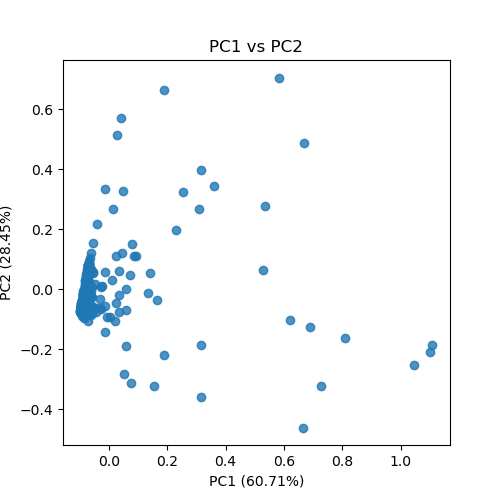

In [88]:
fig = plt.figure(figsize=(5,5))

scatter = plt.scatter(transformed_data[:, 0], transformed_data[:, 1], alpha=0.8)

plt.title('PC1 vs PC2')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')

# Add interactive cursor
cursor = mplcursors.cursor(scatter, hover=False)  # 'hover=False' means click is required

@cursor.connect("add")
def on_add(sel):
    # Get the x, y coordinates of the selected point
    x, y = sel.target
    
    # Calculate distances to find the closest point
    distances = np.sqrt((transformed_data[:, 0] - x)**2 + (transformed_data[:, 1] - y)**2)
    idx = np.argmin(distances)
       
    # Set the annotation text to show the index
    sel.annotation.set_text(f'Index: {idx}\nTheta: {theta_val[idx]}')
    
    # Optional: Print additional info to console
    print(f"Selected point index: {idx}")
    print(f"PCA coordinates: {transformed_data[idx]}")

plt.show()